# Investigating the Effect of Noise Reduction Filters on Image Edges


In image processing, the main goal of **Noise Reduction Filters** is to reduce the noise present in an image. However, an important consideration is that these filters may also remove or modify important image information, especially **edges**, while reducing noise.

Edges are one of the most important features of an image because they define the boundaries between different regions, objects, and fine details. Therefore, analyzing the effect of filtering methods on edges is highly important.


In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

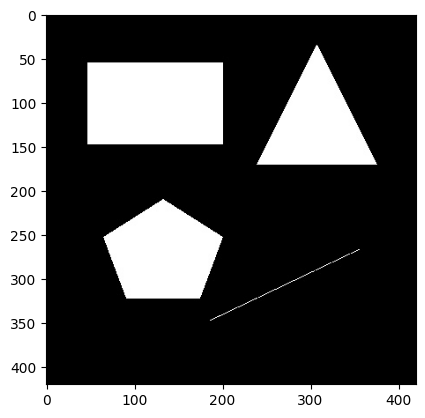

In [40]:
img = cv2.cvtColor(cv2.imread('shape.jpg'),cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.show()

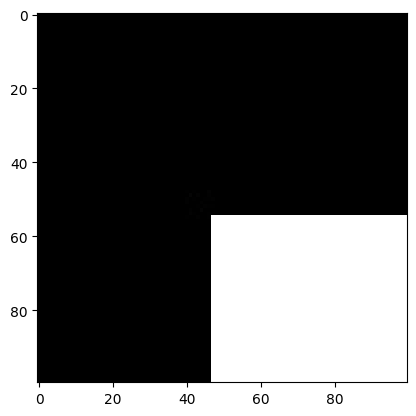

In [41]:
plt.imshow(img[:100,:100,:])
plt.show()

# Filter Effect

# Effect of Mean Filter on Image Edges



The **Mean Filter** smooths an image by replacing each pixel value with the average value of its neighboring pixels.


For example, in an image containing a sharp edge between a black and a white region, the pixel intensities around the edge change suddenly:



```

0 0 0 0 255 255 255

```



However, after applying the **Mean Filter**, the new pixel values are obtained by averaging the surrounding pixels:



```

0 20 80 170 230 255 255


```


As a result:



- Pure black and white values are converted into intermediate gray values.

- The intensity variation across the edge is reduced.

- The edge becomes smoother and blurred.



Therefore, the **Mean Filter** not only reduces noise but also causes **degradation of edge information**.



In [42]:
img_blur = cv2.blur(img,(7,7))

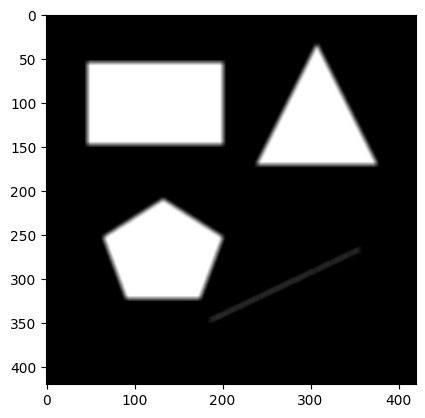

In [43]:
plt.imshow(img_blur)
plt.show()

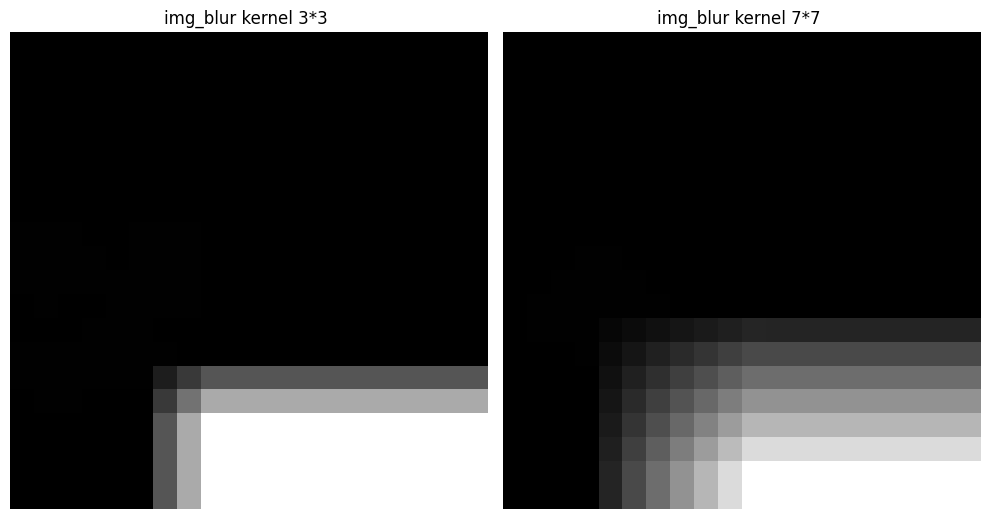

In [47]:
img_blur_kernel3 = cv2.blur(img,(3,3))
img_blur_kernel7 = cv2.blur(img,(7,7))

plt.figure(figsize=(10,8))

plt.subplot(1,2,1)
plt.imshow(img_blur_kernel3[40:60,40:60,:])
plt.title('img_blur kernel 3*3 ')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_blur_kernel7[40:60,40:60,:])
plt.title('img_blur kernel 7*7 ')
plt.axis('off')

plt.tight_layout()
plt.show()



# Effect of Increasing Kernel Size

As the **kernel size** increases, more pixels participate in the averaging process.

For example:

- Small kernel such as **3×3** → Less smoothing and smaller changes.
- Large kernel such as **11×11** → Stronger smoothing and more blurring.

By increasing the kernel size:

- A larger region of the image is combined together.
- Edges become smoother and less sharp.
- Small details and fine structures in the image may be removed.

Therefore, selecting an appropriate **kernel size** requires a trade-off between **noise reduction** and **detail preservation**.

---

---
---

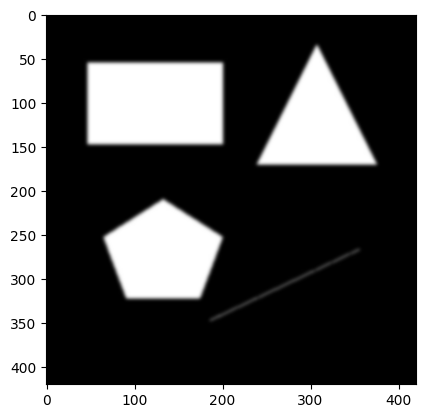

In [48]:
img_gaussian = cv2.GaussianBlur(img,(11,11),2)

plt.imshow(img_gaussian)
plt.show()

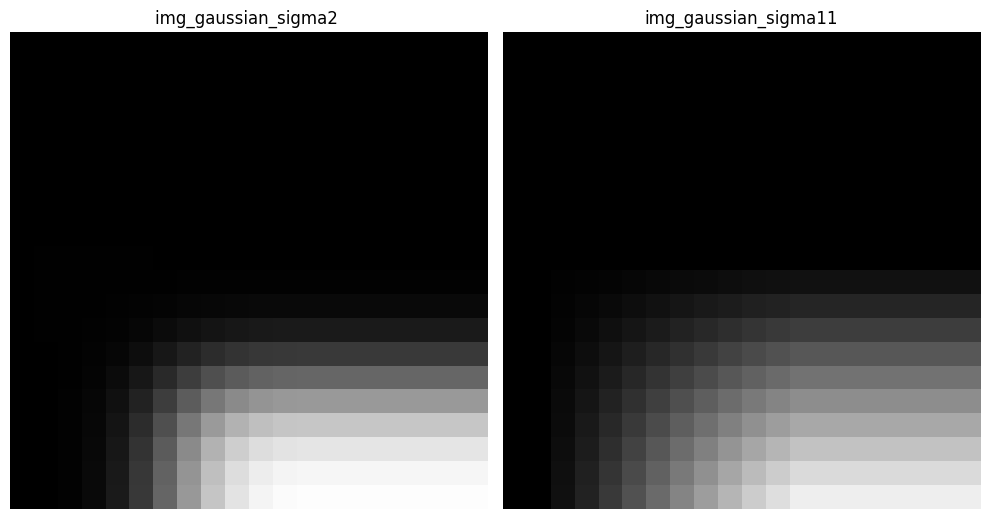

In [51]:
img_gaussian_sigma2 = cv2.GaussianBlur(img,(11,11),2)
img_gaussian_sigma11 = cv2.GaussianBlur(img,(11,11),11)


plt.figure(figsize=(10,8))

plt.subplot(1,2,1)
plt.imshow(img_gaussian_sigma2[40:60,40:60,:])
plt.title('img_gaussian_sigma2 ')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_gaussian_sigma5[40:60,40:60,:])
plt.title('img_gaussian_sigma11')
plt.axis('off')

plt.tight_layout()
plt.show()



# Effect of Gaussian Filter on Image Edges

The **Gaussian Filter** works similarly to the **Mean Filter**, but instead of assigning equal weights to all pixels, it gives higher weights to pixels that are closer to the center of the kernel.

In Gaussian Filtering, an important parameter called **Sigma (σ)** controls the spread of the Gaussian distribution.

Increasing the value of **Sigma** causes:

- A larger neighborhood to contribute to the filtering process.
- More smoothing and stronger blurring of the image.
- Edges to become softer and less distinct.

For example:

```

Small σ  → Better edge preservation
Large σ  → More edge blurring

```

Therefore, the **Gaussian Filter** can also modify the position and intensity of edges, especially when a large Sigma value is used.


---
---
---

# Effect of Median Filter on Image Edges

The **Median Filter** is a nonlinear filter that replaces each pixel value with the **median value of its neighboring pixels**.

Unlike the **Mean** and **Gaussian Filters**, the Median Filter performs very well for removing impulse noises such as:

- **Salt Noise**
- **Pepper Noise**

The main advantages of the **Median Filter** are:

- Outlier pixels are effectively removed.
- The overall structure of the image is preserved.
- Edges are affected less compared with averaging-based filters.

However, if the **kernel size** becomes too large, the Median Filter can also remove fine details and cause loss of important image information.

Therefore, the Median Filter provides a good balance between **noise removal** and **edge preservation**, especially for salt-and-pepper noise.

In [52]:
img_median = cv2.medianBlur(img,3)

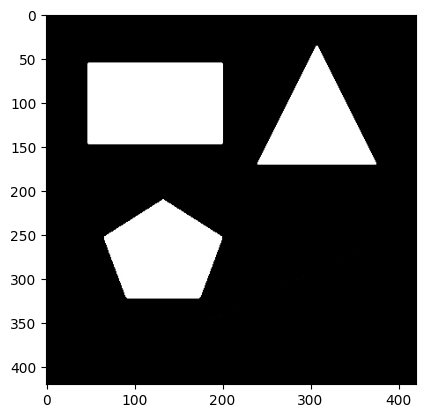

In [53]:
plt.imshow(img_median)
plt.show()

line is not 

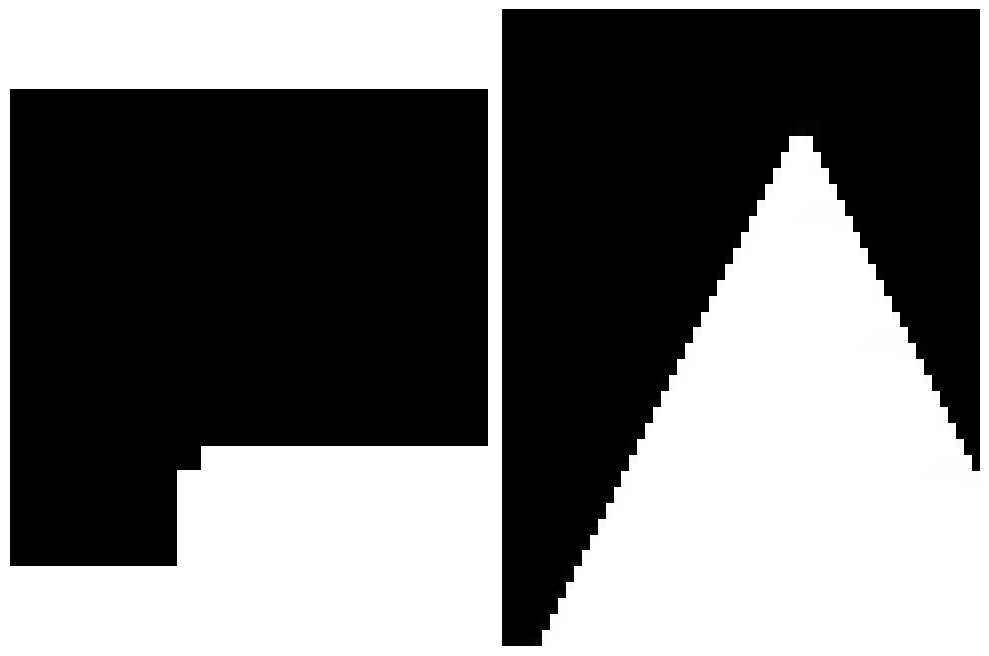

In [54]:
plt.figure(figsize=(10,8))

plt.subplot(1,2,1)
plt.imshow(img_median[40:60,40:60])
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_median[20:100,270:330,:])
plt.axis('off')

plt.tight_layout()
plt.show()



---
---
---

# Effect of Bilateral Filter on Image Edges

The **Bilateral Filter** is an advanced smoothing filter that considers not only the spatial distance between pixels but also the difference in their intensity values.

This filter evaluates two main factors:

1. **Spatial Distance**

   The distance between neighboring pixels.

2. **Intensity Difference**

   The difference in brightness (or color intensity) between pixels.

In conventional filters such as the **Gaussian Filter**:

- Pixels from both sides of an edge are combined together.
- This averaging process reduces the intensity difference and causes the edge to become blurred.

However, in the **Bilateral Filter**:

- If the intensity difference between pixels is large, their contribution to each other becomes very small.
- As a result, pixels from different regions are prevented from being excessively mixed.

For example:

```

Dark region: 0
Bright region: 255

```

This large intensity difference allows the **Bilateral Filter** to keep these two regions separated.

As a result:

- Noise is reduced.
- Edges are preserved.
- Blurring across object boundaries is significantly reduced.

Therefore, the **Bilateral Filter** provides effective smoothing while maintaining important edge information.


In [55]:
img_bilateral = cv2.bilateralFilter(img,11,sigmaColor=50,sigmaSpace=10)

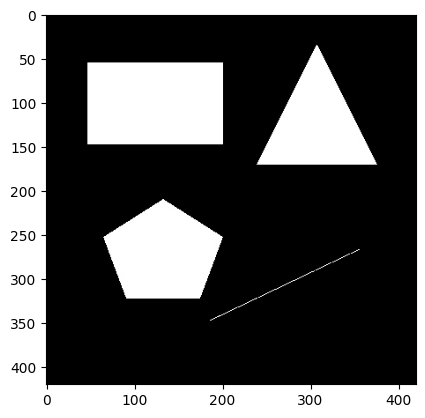

In [56]:
plt.imshow(img_bilateral)
plt.show()

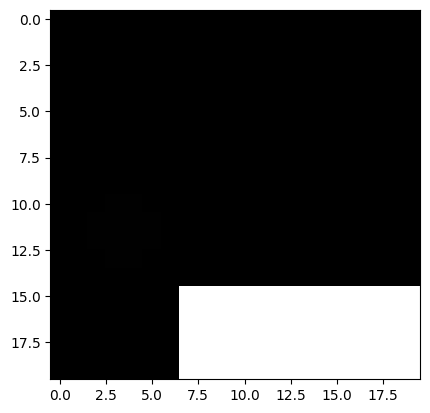

In [57]:
plt.imshow(img_bilateral[40:60,40:60])
plt.show()